# Évaluation Single-Task Online — EWC+MLP (Dataset 2 — Equipment Monitoring)

| Paramètre | Valeur |
|-----------|--------|
| **Modèle** | EWC+MLP (`EWCMlpClassifier`) |
| **Dataset** | Equipment Monitoring (Dataset 2) — tous équipements fusionnés |
| **Scénario** | Single-task, apprentissage **online** (un échantillon à la fois) |
| **Évaluation** | Prequential (predict-then-update) + contribution des variables |
| **Expérience** | `exp_030_ewc_monitoring_single_task` |
| **Sprint** | S11 |

**Note** : Les métriques batch (`exp_030`) utilisent `batch_size=32, epochs=20`.  
Ce notebook évalue le mode **online strict** (`batch_size=1`, une passe sur les données) — résultats distincts et complémentaires.

In [1]:
# Section 1 — Setup & imports
import json
import sys
from pathlib import Path

# Navigation vers la racine du projet (3 niveaux : monitoring_single_task/cl_eval/notebooks/)
REPO_ROOT = Path().resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, roc_curve

from src.data.monitoring_dataset import get_monitoring_dataloaders_single_task
from src.evaluation.feature_importance import (
    gradient_saliency,
    permutation_importance,
    plot_feature_importance,
    plot_feature_importance_comparison,
)
from src.evaluation.plots import plot_confusion_matrix_grid
from src.models.ewc.ewc_mlp import EWCMlpClassifier
from IPython.display import display, Image

# Constantes
MODEL_NAME    = "EWC+MLP"
EXP_DIR       = REPO_ROOT / "experiments" / "exp_030_ewc_monitoring_single_task"
FIGURES_DIR   = REPO_ROOT / "notebooks" / "figures" / "cl_evaluation" / "ewc" / "monitoring" / "single_task"
CSV_PATH      = REPO_ROOT / "data" / "raw" / "equipment_monitoring" / "Industrial_Equipment_Monitoring_Dataset" / "equipment_anomaly_data.csv"
FEATURE_NAMES = ["temperature", "pressure", "vibration", "humidity"]
SEED          = 42

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Repo root : {REPO_ROOT}")
print(f"CSV exists: {CSV_PATH.exists()}")

Repo root : /home/leonard/Documents/ENAC/cl-embedded
CSV exists: True


## Section 2 — Métriques batch pré-calculées (exp_030)

In [2]:
metrics_path = EXP_DIR / "results" / "metrics_single_task.json"
if metrics_path.exists():
    with open(metrics_path) as f:
        batch_metrics = json.load(f)
    print("Métriques batch (batch_size=32, 20 epochs) :")
    for k, v in batch_metrics.items():
        print(f"  {k:30s}: {v}")
else:
    print(f"[WARN] {metrics_path} introuvable — métriques batch non disponibles")
    batch_metrics = {}

Métriques batch (batch_size=32, 20 epochs) :
  exp_id                        : exp_030_ewc_monitoring_single_task
  accuracy                      : 0.9824104234527687
  f1                            : 0.9052631578947369
  auc_roc                       : 0.9910662769690607
  ram_peak_bytes                : 1171
  inference_latency_ms          : 0.039479820034102886
  n_params                      : 705
  threshold                     : 0.6900000000000001


## Section 3 — Résumé visuel des métriques batch

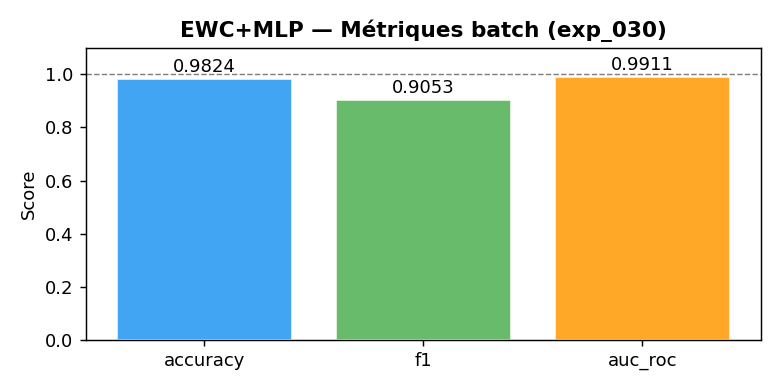

In [3]:
if batch_metrics:
    fig, ax = plt.subplots(figsize=(6, 3), dpi=130)
    metric_keys = ["accuracy", "f1", "auc_roc"]
    vals = [batch_metrics.get(k, 0) for k in metric_keys]
    bars = ax.bar(metric_keys, vals, color=["#2196F3", "#4CAF50", "#FF9800"], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.4f}", ha="center", va="bottom", fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_title(f"{MODEL_NAME} — Métriques batch (exp_030)", fontweight="bold")
    ax.set_ylabel("Score")
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "batch_metrics.png", dpi=130)
    display(Image(str(FIGURES_DIR / "batch_metrics.png")))

## Section 4 — Chargement des données

In [4]:
assert CSV_PATH.exists(), f"CSV introuvable : {CSV_PATH}"

# batch_size=1 pour le mode online ; shuffle=False sur train pour stream reproductible
data = get_monitoring_dataloaders_single_task(
    csv_path=CSV_PATH,
    batch_size=1,
    test_ratio=0.2,
    val_ratio=0.1,
    seed=SEED,
)

# Extraire les tenseurs bruts pour la boucle online et l'analyse de contribution
def loader_to_numpy(loader):
    Xs, ys = [], []
    for x_batch, y_batch in loader:
        Xs.append(x_batch.numpy())
        ys.append(y_batch.numpy())
    return np.concatenate(Xs).squeeze(), np.concatenate(ys).squeeze()

X_train, y_train = loader_to_numpy(data["train_loader"])
X_test,  y_test  = loader_to_numpy(data["test_loader"])

print(f"Train : {X_train.shape}, faulty={y_train.mean():.3f}")
print(f"Test  : {X_test.shape},  faulty={y_test.mean():.3f}")

✅ Seed fixé à 42
Train : (5523, 4), faulty=0.100
Test  : (1535, 4),  faulty=0.100


## Section 5 — Boucle online prequential (predict-then-update)

Protocole : pour chaque échantillon `(x_i, y_i)` :
1. Prédire `ŷ_i` avec l'état courant du modèle (avant de voir `y_i`)
2. Enregistrer `(ŷ_i, y_i)`
3. Effectuer un pas SGD sur `(x_i, y_i)`

Note : `nn.Dropout(p=0.2)` reste actif pendant l'entraînement — réaliste pour MCU embarqué.

In [5]:
model = EWCMlpClassifier(input_dim=4, hidden_dims=[32, 16], dropout=0.2)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
pos_weight = torch.tensor([9.0])  # correction déséquilibre (~10% faulty)
criterion = torch.nn.BCELoss()

all_probs:  list[float] = []
all_labels: list[int]   = []
all_losses: list[float] = []

model.train()  # dropout actif

for i, (xi, yi) in enumerate(zip(X_train, y_train)):
    x_t = torch.from_numpy(xi.astype(np.float32)).unsqueeze(0)  # [1, 4]
    y_t = torch.tensor([[float(yi)]])

    # 1. Prédiction AVANT la mise à jour
    with torch.no_grad():
        prob = model(x_t).item()
    all_probs.append(prob)
    all_labels.append(int(yi))

    # 2. Mise à jour SGD sur ce seul échantillon
    optimizer.zero_grad()
    output = model(x_t)
    loss = criterion(output, y_t)
    loss.backward()
    optimizer.step()
    all_losses.append(loss.item())

prequential_acc = float(np.mean((np.array(all_probs) >= 0.5) == np.array(all_labels)))
print(f"Accuracy prequential (train stream) : {prequential_acc:.4f}")
print(f"Loss moyenne                         : {np.mean(all_losses):.4f}")

/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Accuracy prequential (train stream) : 0.9422
Loss moyenne                         : 0.1947


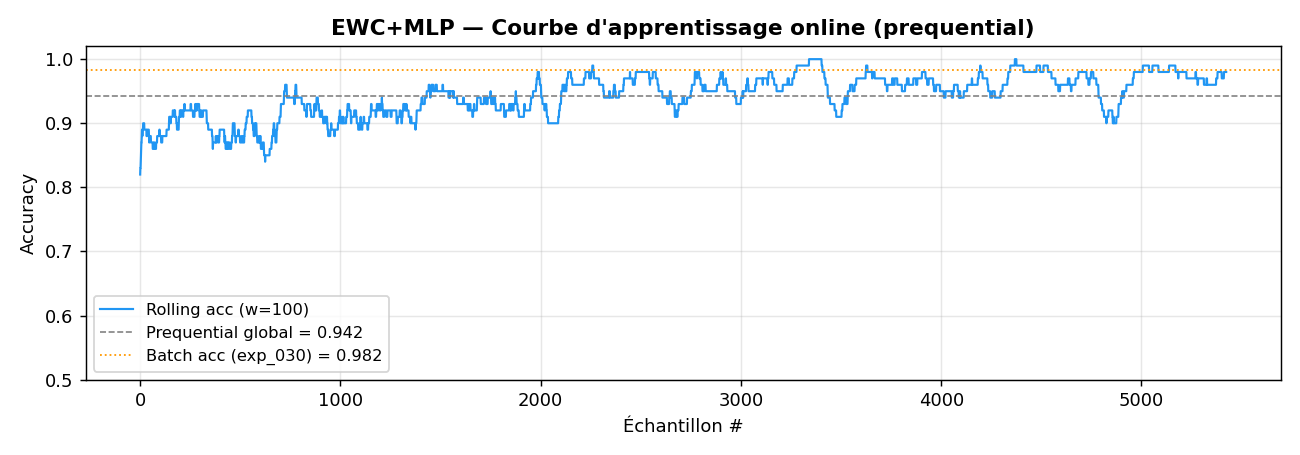

In [6]:
# Courbe d'accuracy prequential rolling (fenêtre=100)
WINDOW = 100
preds_bin = (np.array(all_probs) >= 0.5).astype(int)
labels_arr = np.array(all_labels)
rolling_acc = np.convolve((preds_bin == labels_arr).astype(float),
                           np.ones(WINDOW) / WINDOW, mode="valid")

fig, ax = plt.subplots(figsize=(10, 3.5), dpi=130)
ax.plot(rolling_acc, color="#2196F3", linewidth=1.2, label=f"Rolling acc (w={WINDOW})")
ax.axhline(prequential_acc, color="gray", linestyle="--", linewidth=0.9, label=f"Prequential global = {prequential_acc:.3f}")
if batch_metrics.get("accuracy"):
    ax.axhline(batch_metrics["accuracy"], color="#FF9800", linestyle=":", linewidth=1,
               label=f"Batch acc (exp_030) = {batch_metrics['accuracy']:.3f}")
ax.set_xlabel("Échantillon #")
ax.set_ylabel("Accuracy")
ax.set_title(f"{MODEL_NAME} — Courbe d'apprentissage online (prequential)", fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0.5, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "prequential_rolling_acc.png", dpi=130)
display(Image(str(FIGURES_DIR / "prequential_rolling_acc.png")))

## Section 6 — Évaluation finale sur le test set

In [7]:
model.eval()
with torch.no_grad():
    X_test_t = torch.from_numpy(X_test.astype(np.float32))
    test_probs = model(X_test_t).numpy().flatten()

THRESHOLD = batch_metrics.get("threshold", 0.5)
test_preds = (test_probs >= THRESHOLD).astype(int)
test_acc   = float(np.mean(test_preds == y_test.astype(int)))
test_auc   = roc_auc_score(y_test, test_probs)

from sklearn.metrics import f1_score
test_f1 = f1_score(y_test.astype(int), test_preds, zero_division=0)

print(f"Test accuracy  : {test_acc:.4f}")
print(f"Test AUC-ROC   : {test_auc:.4f}")
print(f"Test F1        : {test_f1:.4f}")
print(f"Threshold used : {THRESHOLD:.2f}")

Test accuracy  : 0.9759
Test AUC-ROC   : 0.9910
Test F1        : 0.8635
Threshold used : 0.69


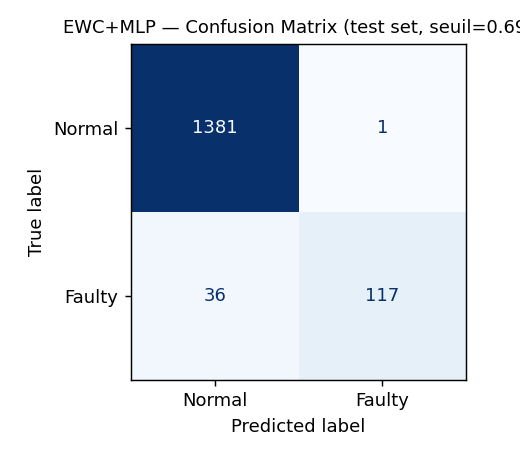

In [8]:
# Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test.astype(int), test_preds)
fig, ax = plt.subplots(figsize=(4, 3.5), dpi=130)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Faulty"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"{MODEL_NAME} — Confusion Matrix (test set, seuil={THRESHOLD:.2f})", fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=130)
display(Image(str(FIGURES_DIR / "confusion_matrix.png")))

## Section 7 — Courbe ROC

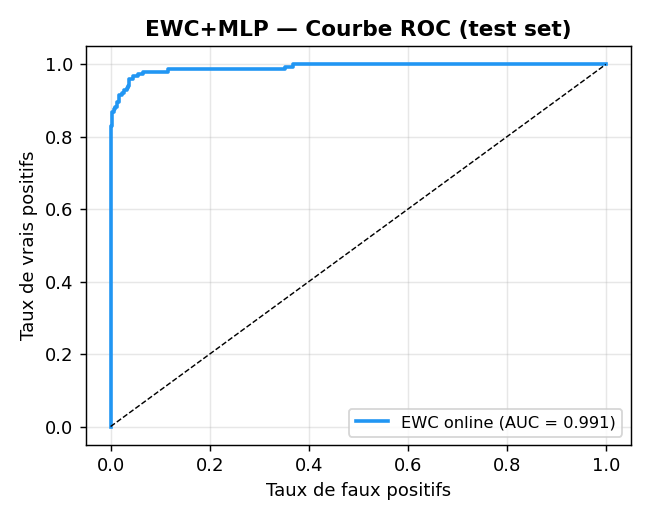

In [9]:
fpr, tpr, _ = roc_curve(y_test.astype(int), test_probs)

fig, ax = plt.subplots(figsize=(5, 4), dpi=130)
ax.plot(fpr, tpr, color="#2196F3", linewidth=2, label=f"EWC online (AUC = {test_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.set_title(f"{MODEL_NAME} — Courbe ROC (test set)", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "roc_curve.png", dpi=130)
display(Image(str(FIGURES_DIR / "roc_curve.png")))

## Section 8 — Espace des features (PCA 2D)

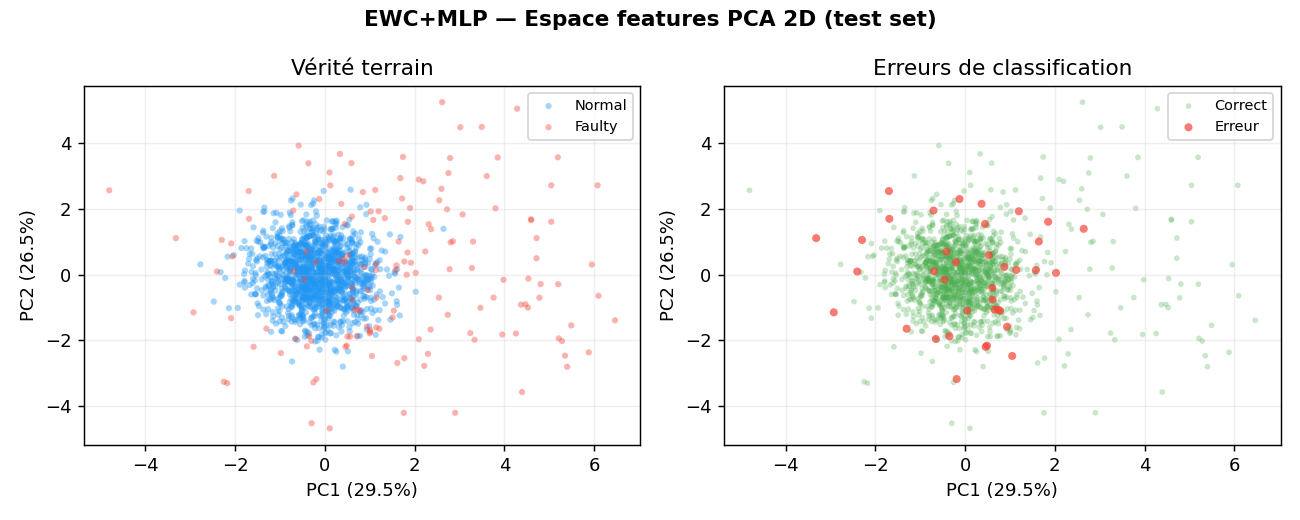

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
X_test_2d = pca.fit_transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=130)

# Gauche : vérité terrain
for label, name, c in [(0, "Normal", "#2196F3"), (1, "Faulty", "#F44336")]:
    mask = y_test.astype(int) == label
    axes[0].scatter(X_test_2d[mask, 0], X_test_2d[mask, 1], c=c, alpha=0.4,
                    s=12, label=name, edgecolors="none")
axes[0].set_title("Vérité terrain")
axes[0].legend(fontsize=8)

# Droite : erreurs de classification
correct = (test_preds == y_test.astype(int))
axes[1].scatter(X_test_2d[correct, 0],  X_test_2d[correct, 1],  c="#4CAF50", alpha=0.3, s=10, label="Correct",   edgecolors="none")
axes[1].scatter(X_test_2d[~correct, 0], X_test_2d[~correct, 1], c="#F44336", alpha=0.7, s=20, label="Erreur",    edgecolors="none")
axes[1].set_title("Erreurs de classification")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.grid(True, alpha=0.2)

fig.suptitle(f"{MODEL_NAME} — Espace features PCA 2D (test set)", fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "pca_feature_space.png", dpi=130)
display(Image(str(FIGURES_DIR / "pca_feature_space.png")))

## Section 9 — Tableau récapitulatif

In [11]:
from src.evaluation.memory_profiler import profile_forward_pass

x_dummy = torch.randn(1, 4)
lat_report = profile_forward_pass(lambda: model(x_dummy), n_runs=100)

n_params = sum(p.numel() for p in model.parameters())

print("=" * 55)
print(f"  Modèle          : {MODEL_NAME}")
print(f"  Dataset         : Equipment Monitoring (single-task)")
print("-" * 55)
print(f"  Paramètres      : {n_params}")
print(f"  RAM batch acc.  : {batch_metrics.get('ram_peak_bytes', 'N/A')} B")
print(f"  Latence inférence: {lat_report['mean_ms']:.3f} ms")
print("-" * 55)
print(f"  Acc. batch (20 epochs) : {batch_metrics.get('accuracy', 'N/A'):.4f}")
print(f"  Acc. prequential online: {prequential_acc:.4f}")
print(f"  Acc. test (post-online): {test_acc:.4f}")
print(f"  AUC-ROC (test)         : {test_auc:.4f}")
print(f"  F1 (test)              : {test_f1:.4f}")
print("-" * 55)
budget_ok = batch_metrics.get('ram_peak_bytes', 0) <= 65536
print(f"  Budget RAM 64 Ko : {'✅ OK' if budget_ok else '❌ DÉPASSÉ'}")
print("=" * 55)

TypeError: profile_forward_pass() missing 1 required positional argument: 'input_shape'

## Section 10 — Contribution individuelle des variables

Deux méthodes :
- **Permutation importance** (modèle-agnostique) : permute une colonne → mesure la chute d'accuracy
- **Gradient saliency** (EWC-specific, PyTorch) : `mean |∂ŷ/∂x|` sur le test set

Les deux opèrent dans l'**espace d'entrée brut** (4 features Z-score normalisées).

In [12]:
model.eval()

# Fonction de prédiction compatible avec permutation_importance
def ewc_predict_fn(X_np: np.ndarray) -> np.ndarray:
    with torch.no_grad():
        return model(torch.from_numpy(X_np.astype(np.float32))).numpy().flatten()

print("Calcul de la permutation importance (n_repeats=10)...")
perm_imp = permutation_importance(
    predict_fn=ewc_predict_fn,
    X=X_test,
    y=y_test,
    feature_names=FEATURE_NAMES,
    n_repeats=10,
    random_state=SEED,
    threshold=THRESHOLD,
)

print("\nPermutation Importance :")
for feat, score in perm_imp.items():
    print(f"  {feat:15s}: {score:+.4f}")

Calcul de la permutation importance (n_repeats=10)...

Permutation Importance :
  temperature    : +0.0619
  vibration      : +0.0468
  pressure       : +0.0175
  humidity       : +0.0045


In [13]:
print("Calcul du gradient saliency...")
grad_sal = gradient_saliency(
    model=model,
    X=X_test,
    feature_names=FEATURE_NAMES,
)

print("\nGradient Saliency (mean |∂ŷ/∂x|) :")
for feat, score in sorted(grad_sal.items(), key=lambda kv: kv[1], reverse=True):
    print(f"  {feat:15s}: {score:.6f}")

Calcul du gradient saliency...

Gradient Saliency (mean |∂ŷ/∂x|) :
  temperature    : 0.034355
  vibration      : 0.020147
  pressure       : 0.018827
  humidity       : 0.015957


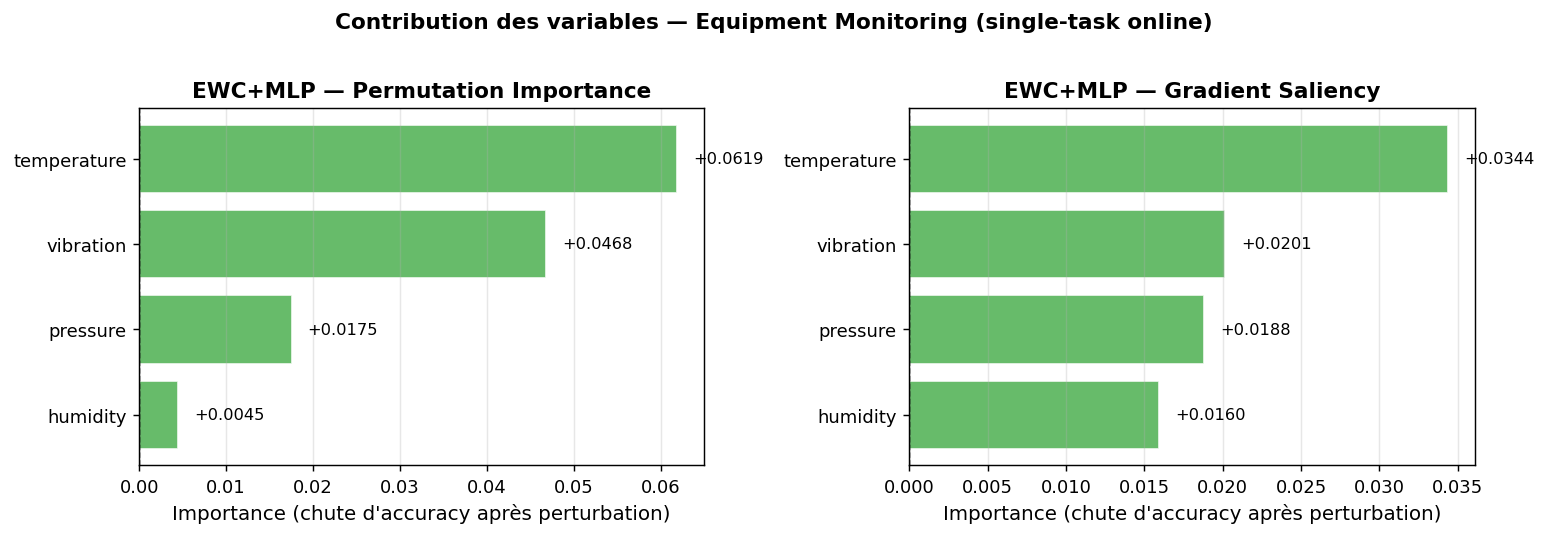

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=130)

# Permutation importance
from src.evaluation.feature_importance import plot_feature_importance
_ = plot_feature_importance(
    perm_imp,
    title=f"{MODEL_NAME} — Permutation Importance",
    ax=axes[0],
)

# Gradient saliency (normalisation pour comparaison visuelle)
grad_sorted = dict(sorted(grad_sal.items(), key=lambda kv: kv[1], reverse=True))
_ = plot_feature_importance(
    grad_sorted,
    title=f"{MODEL_NAME} — Gradient Saliency",
    color="#FF9800",
    ax=axes[1],
)

plt.suptitle("Contribution des variables — Equipment Monitoring (single-task online)",
             fontweight="bold", fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "feature_importance_side_by_side.png", dpi=130, bbox_inches="tight")
display(Image(str(FIGURES_DIR / "feature_importance_side_by_side.png")))

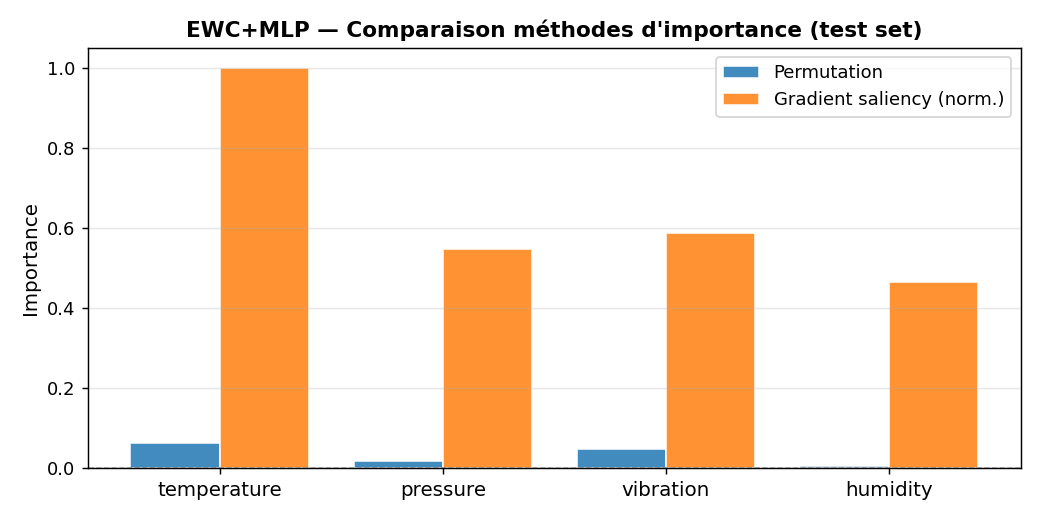


Conclusion :
  Variable la plus importante (permutation) : temperature
  Variable la plus sensible (gradient)      : temperature
  → Les deux méthodes s'accordent.


In [15]:
# Normaliser gradient saliency sur [0,1] pour comparaison directe avec permutation
max_grad = max(grad_sal.values()) or 1.0
grad_norm = {k: v / max_grad for k, v in grad_sal.items()}

fig = plot_feature_importance_comparison(
    {"Permutation": perm_imp, "Gradient saliency (norm.)": grad_norm},
    feature_names=FEATURE_NAMES,
    title=f"{MODEL_NAME} — Comparaison méthodes d'importance (test set)",
)
fig.savefig(FIGURES_DIR / "feature_importance_comparison.png", dpi=130)
display(Image(str(FIGURES_DIR / "feature_importance_comparison.png")))

print("\nConclusion :")
top_perm = max(perm_imp, key=perm_imp.get)
top_grad = max(grad_sal, key=grad_sal.get)
print(f"  Variable la plus importante (permutation) : {top_perm}")
print(f"  Variable la plus sensible (gradient)      : {top_grad}")
if top_perm == top_grad:
    print("  → Les deux méthodes s'accordent.")
else:
    print("  → Divergence entre les deux méthodes — à analyser.")

In [16]:
# Sauvegarde des résultats d'importance
importance_results = {
    "model": MODEL_NAME,
    "dataset": "equipment_monitoring",
    "scenario": "single_task_online",
    "test_accuracy": test_acc,
    "test_auc_roc": test_auc,
    "prequential_accuracy": prequential_acc,
    "permutation_importance": perm_imp,
    "gradient_saliency": grad_sal,
}

out_path = EXP_DIR / "results" / "feature_importance.json"
with open(out_path, "w") as f:
    json.dump(importance_results, f, indent=2)

print(f"Résultats sauvegardés : {out_path}")
print("\n✅ Notebook EWC single-task online — terminé.")

Résultats sauvegardés : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_030_ewc_monitoring_single_task/results/feature_importance.json

✅ Notebook EWC single-task online — terminé.
